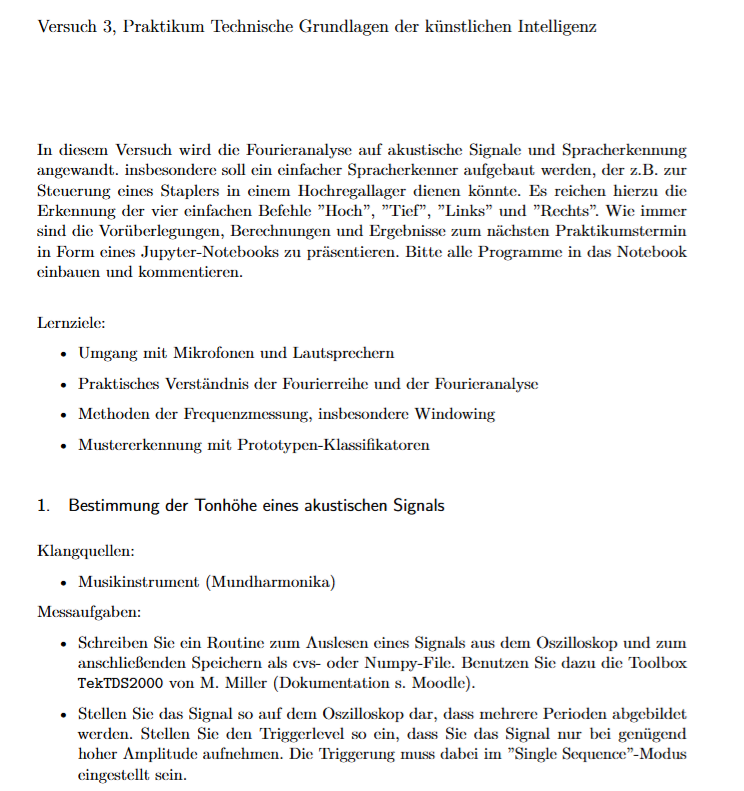

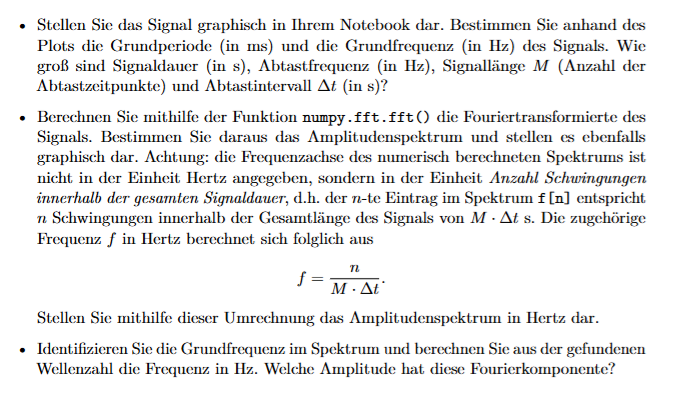


In [222]:
# Imports
import sys
import pandas as pd
import matplotlib.pyplot as plt
import pyaudio
import numpy as np
import os
import re
from scipy.signal import find_peaks, chirp, spectrogram
from IPython.display import Audio


print(sys.executable)

c:\Users\justi\AppData\Local\Programs\Python\Python313\python.exe


-------------------------------------------
# Aufgabe 1
---
#### Mundharmonika
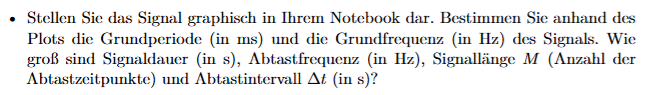
------

In [223]:
# conv für CVS
def conv(x):
    return float(x.replace(',','.'))

# Plot functions
def plotstart():
    plt.figure(figsize=(10,4))

# Finalisiert den Plot: entfernt doppelte Legendeneinträge, setzt Titel und Achsenbeschriftungen,
# aktiviert Gitternetz, platziert die Legende oben rechts, optimiert das Layout und zeigt den Plot an.

def plotend(ueberschrift, xlabel, ylabel, grid=True):
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.title(f" {ueberschrift}")
    plt.xlabel(f"{xlabel}")
    plt.ylabel(f"{ylabel}")
    if(grid == True): plt.grid(True, which='both')
    plt.minorticks_on()
    plt.legend(loc='upper right')   #legende oben rechts
    plt.tight_layout()
    plt.show()

# Methode zur CSV einlesung
def plot(x, y):
    plt.plot(x, y)     # weniger Punkte

def readAndPlotCSV(dateiname, plot):
    data = np.genfromtxt(
        dateiname,
        delimiter=';',
        skip_header=2,
        converters={0: conv, 1: conv},
        autostrip=True
    )

    t = data[:, 0]      # Zeit in ms
    u = data[:, 1]      # Spannung in mV
    t = t - t[0]        # Verschiebt die Zeitreihe so, dass sie bei 0 beginnt
    plotstart()
    plt.plot(t[::10], u[::10])     # weniger Punkte
    plt.xlim(5, 15)                # kleinerer Bereich
    plotend("Mundharmonika", "Zeit in ms", "Spannung in mV")

    return t, u



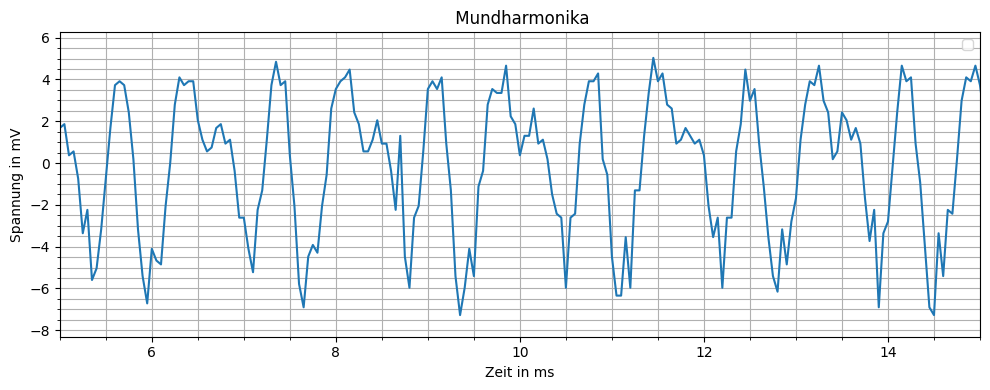

10004


In [224]:

csvFile = "C:/Users/justi/OneDrive/Desktop/Semester 3/5. Technische Grundlagen von KI/KI_Fouriranalyse/Messungen/Harmonika/Harmonika.csv"
t, u = readAndPlotCSV(csvFile, plot=True)

'''
Ablesen der Werte direkt vom Plot:
Grundperiode in ms:

T_0 = 7,65 - 5,95 = 0,0017s = 1,7ms

Grundfrequenz:
f = 1/T = 1/0.0017s = 588 Hz
'''

f_0 = 588 # Hz Grundfrequenz
T_0 = 0.0017 #s oder 1,7ms wenn durch 1000 geteilt Grundperiode

signaldauer = (t[-1] - t[0]) / 1000   # in Sekunden
abtastintervall = (t[1] - t[0]) / 1000 # in Hz
abtastfreq = 1/abtastintervall # Ergibt 4,99e^-6, also 1/0,005ms -> 200,000 Hz 
signallaenge = len(t) # Wir haben 1004 Messpunkte
print(signallaenge)

Betrachtet wird die periode zwischen 5,95ms - 7, 65 ms

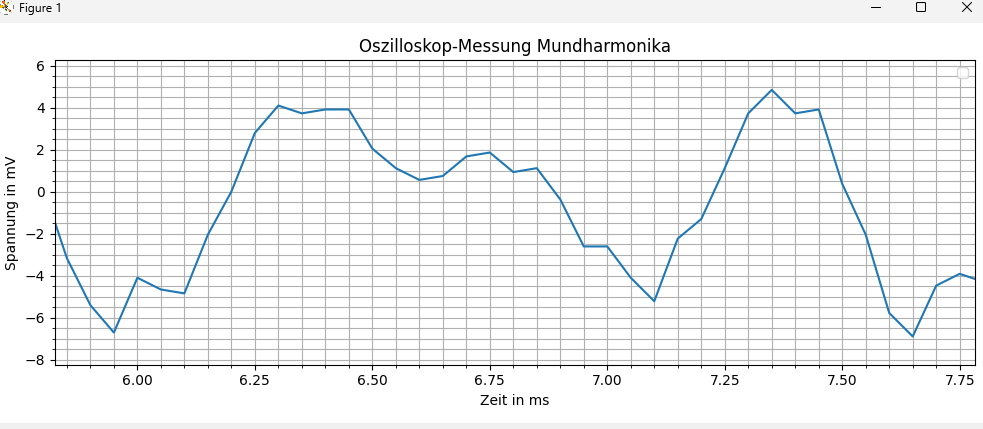

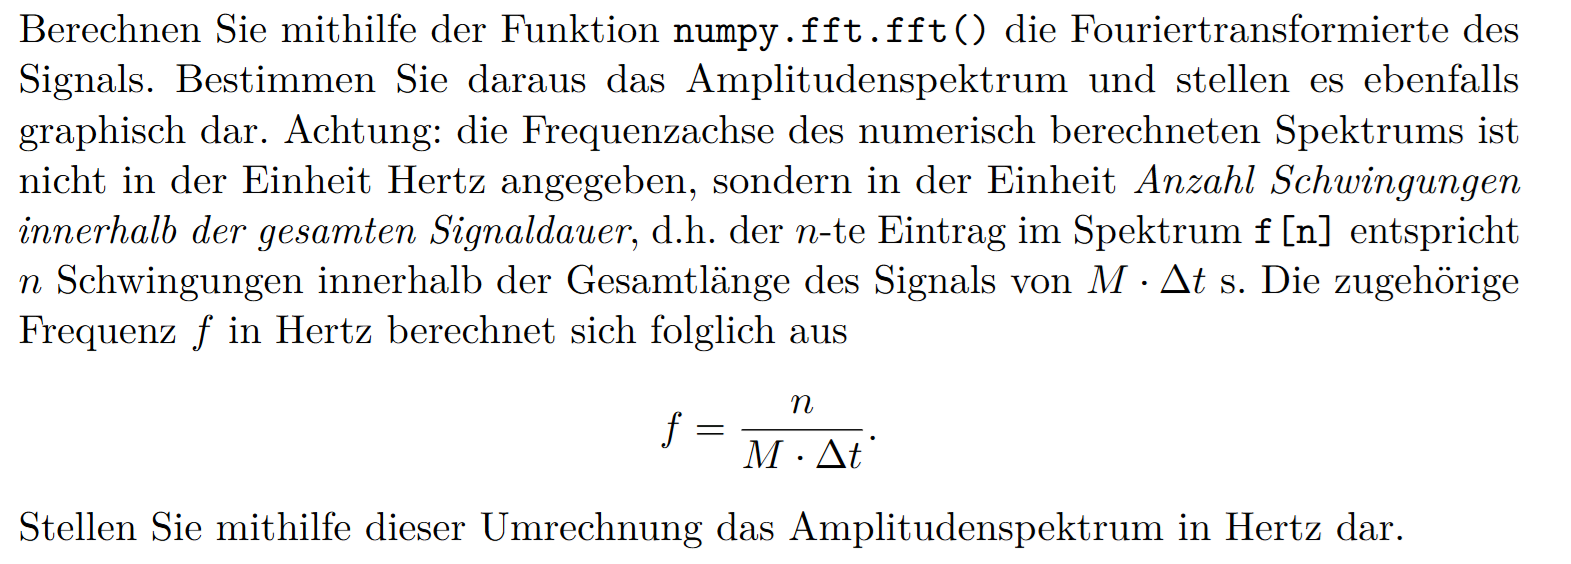



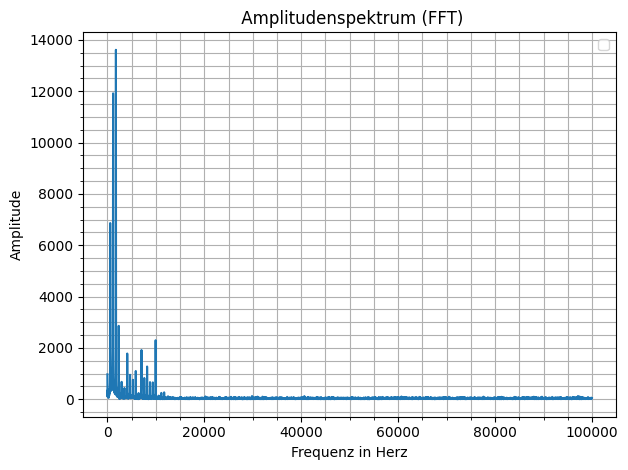

In [225]:

# Fouriertransformation mit numpy.fft.fft()
U = np.fft.fft(u)

# Amplitude
A = np.abs(U)

#                          
 
M = len(u)
dt = (t[1] - t[0])/1000

# Frequenzachse
n = np.arange(M)
f = n / (M * dt)

# erste Hälfte
amplitudenspektrum = A[:M//2] # Amplitudenspektrum
frequenzen = f[:M//2] # Frequenzen

plot(frequenzen, amplitudenspektrum)
plotend(ueberschrift="Amplitudenspektrum (FFT)", xlabel="Frequenz in Herz", ylabel="Amplitude")

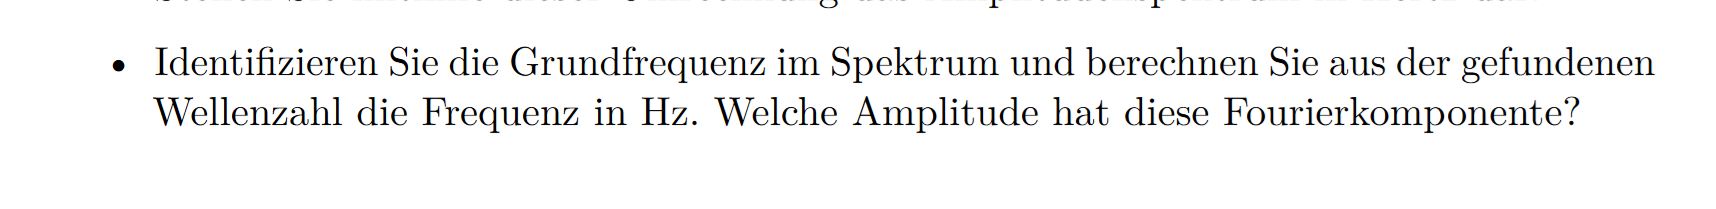

In [226]:
# Alle Peaks finden
peaks, properties = find_peaks(amplitudenspektrum, height=np.max(amplitudenspektrum)*0.05)

# den ersten Peak > 0 nehmen (Grundfrequenz)
first_peak = peaks[0]
f0 = frequenzen[first_peak]
A0 = amplitudenspektrum[first_peak]

print("Grundfrequenz (Hz):", f0) # Zwischen c#5 und D5
print("Amplitude:", A0)

Grundfrequenz (Hz): 579.7680927630103
Amplitude: 6864.807931649934


-------------------------------------------
# Aufgabe 2
---
#### Fourieranalyse lang andauernder Signale
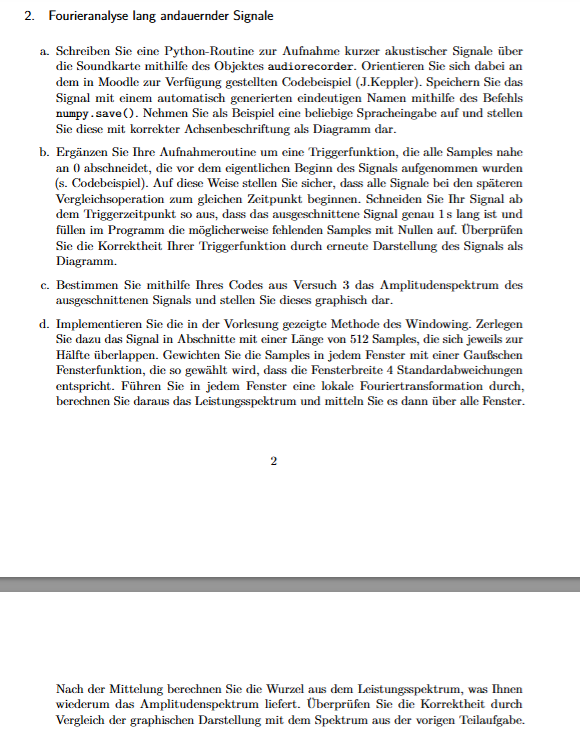
---------

In [227]:
def remove_initial_spike(signal, fs=44100, spike_threshold=60):
    # Prüfe die ersten 100 ms
    check_samples = int(fs * 0.1)

    if np.max(np.abs(signal[:check_samples])) > spike_threshold:
        delete_samples = int(fs * 0.347)  # 250 ms löschen
        print("Spike erkannt -> 250 ms entfernt")
        return signal[delete_samples:]

    return signal



def clean_Data(signal):
    fs = 44100
    duration = 1.0
    threshold = 4   # neuer Trigger

    # 1. Spike entfernen (falls Spike, 250 ms entfernen)
    signal = remove_initial_spike(signal)

    # 2. Sprachstart: erster Punkt, der Amplitude > 10 hat
    idx = np.argmax(np.abs(signal) > threshold)



    # 3. Eine Sekunde ausschneiden
    N = int(fs * duration)
    cut = signal[idx : idx + N]

    # 4. Padding falls zu kurz
    if len(cut) < N:
        cut = np.concatenate([cut, np.zeros(N - len(cut))])

    # 5. Zeitachse
    t = np.arange(len(cut)) / fs
    return t, cut


def ampspec(signalwert, zeitachse):
    # Abtastintervall 
    dt = zeitachse[1] - zeitachse[0]
    fs = 1 / dt

    # FFT
    U = np.fft.fft(signalwert)
    A = np.abs(U)

    M = len(signalwert)

    # Frequenzachse richtig
    freqs = np.fft.fftfreq(M, d=dt)

    # nur positive Frequenzen
    mask = freqs >= 0

    plotstart()
    plot(freqs[mask], A[mask])
    plotend(ueberschrift="Amplitudenspektrum (FFT)",
            xlabel="Frequenz in Hz",
            ylabel="Amplitude")




Signal geladen aus: C:/Users/justi/OneDrive/Desktop/Semester 3/5. Technische Grundlagen von KI/KI_Fouriranalyse/Messungen/Nikita/Nikita_Hoch0002.npy


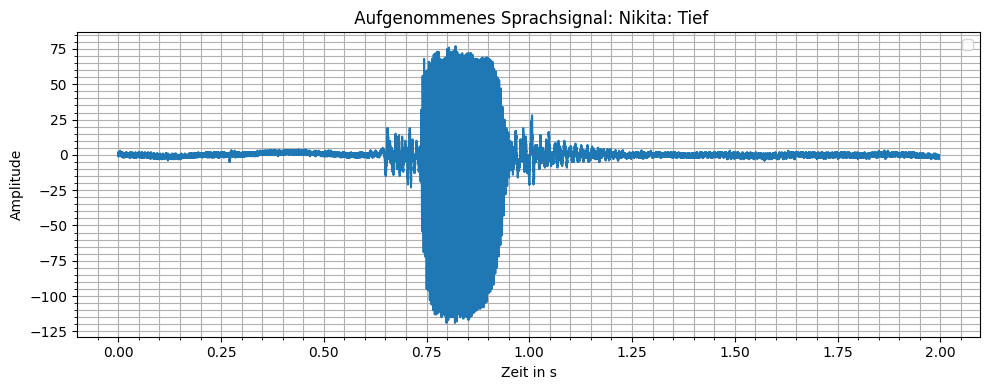

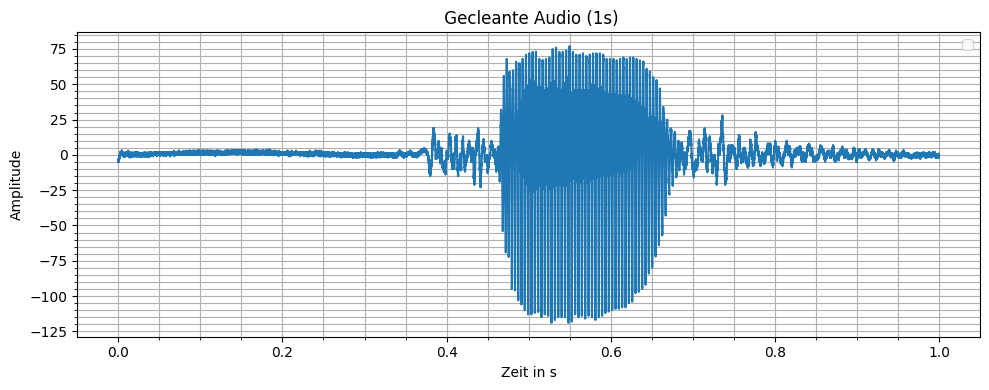

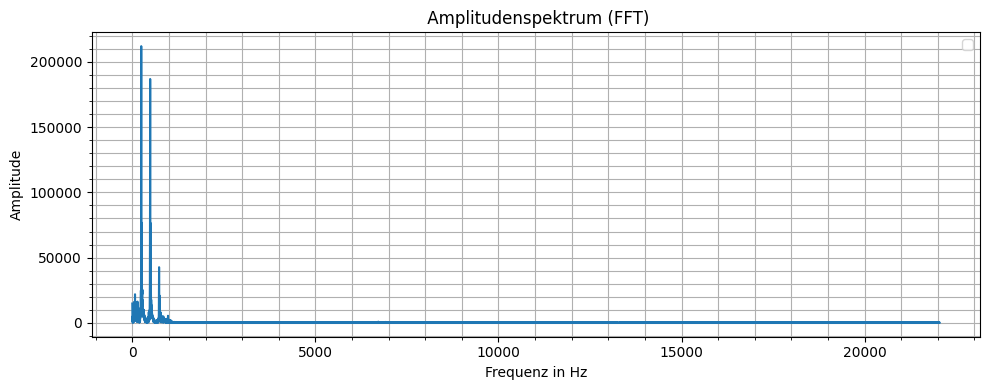

In [277]:
from IPython.display import Audio

filename = "C:/Users/justi/OneDrive/Desktop/Semester 3/5. Technische Grundlagen von KI/KI_Fouriranalyse/Messungen/Nikita/Nikita_Hoch0002.npy"
signal = np.load(filename)
fs = 44100  

t_cut, u_cut = clean_Data(signal)

print(f"Signal geladen aus: {filename}")

t = np.arange(len(signal)) / fs

plotstart()
plot(t, signal)
plotend("Aufgenommenes Sprachsignal: Nikita: Tief", "Zeit in s", "Amplitude")

plotstart()
plot(t_cut, u_cut)
plotend("Gecleante Audio (1s)", "Zeit in s", "Amplitude")

ampspec(signalwert=u_cut, zeitachse=t_cut)

Audio(u_cut, rate=44100)


Test versuche wie man eine Numpy audio abspielt

In [229]:
from IPython.display import Audio
import librosa

def playAudioFilename(filename):
    x = np.load(filename)
    fs = 44100  # deine bekannte Samplingrate
    T = len(x) / fs


    print("Audio shape:", x.shape)
    print("Abtastfrequenz:", fs, "Hz")
    print("Dauer:", T, "s")
    
    return x, fs

def playAudioSignal(signal):
    return Audio(data=signal, rate=44100)

In [230]:

# Play Audio
test = "C:/Users/justi/OneDrive/Desktop/Semester 3/5. Technische Grundlagen von KI/KI_Fouriranalyse/Messungen/Justin/Justin_Hoch0000.npy"
x, fs = playAudioFilename(test)
Audio(x, rate=fs)


Audio shape: (88064,)
Abtastfrequenz: 44100 Hz
Dauer: 1.9969160997732427 s


Richtigen Ausgaben

In [231]:
# Ausgabe als Audio
print("Cutted Version")
Audio(u_cut, rate=fs) # Cutted version


Cutted Version


In [232]:
print("Original Version")
Audio(signal, rate=fs) # Original Version

Original Version


Windowing

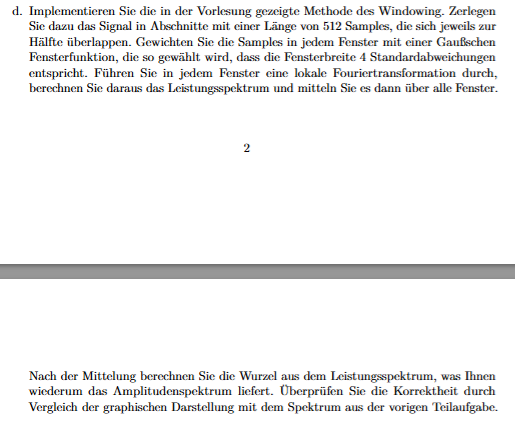

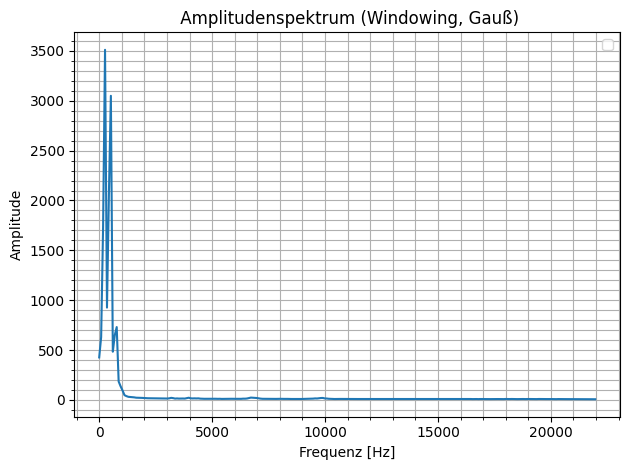

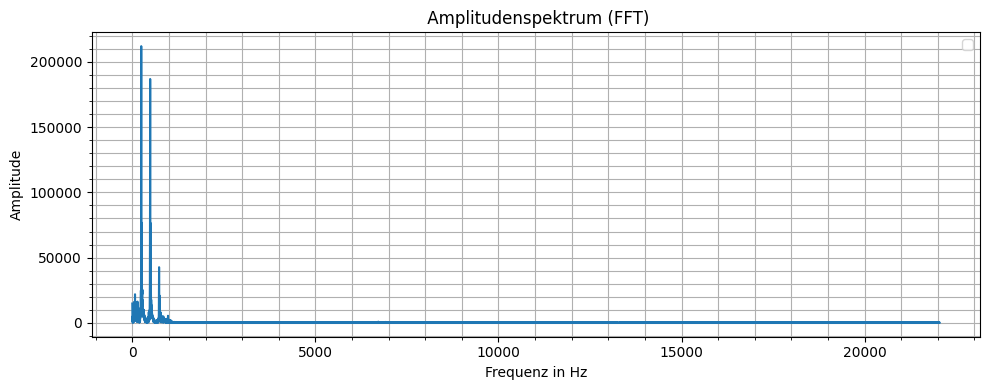

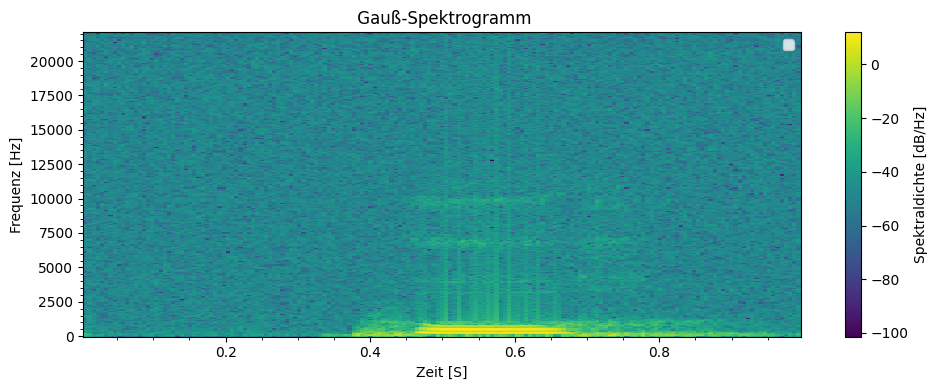

In [278]:
import warnings
warnings.filterwarnings("ignore")

# Samplingrate fs = 44100
# L = Samplesize
def gauss_window_fft(signal):
    fs = 44100 
    L = 512

    # 1. Gaußfenster erzeugen
    sigma = L / 4  # Fensterbreite
    mu = (L - 1) / 2  # Mittelpunkt
    gauss_window = np.exp(-0.5 * ((np.arange(L) - mu) / sigma)**2)

    # 2. Fensterung (50 % Overlap)
    step = L // 2
    segments = []

    for start in range(0, len(signal) - L + 1, step):
        segment = signal[start:start + L]
        segment = segment * gauss_window  # Gauß-Fenster anwenden
        segments.append(segment)

    segments = np.array(segments)

    # 3. FFT jedes Fensters --> Leistungsspektrum
    spectra = np.abs(np.fft.fft(segments, axis=1))**2

    # 4. Leistungsspektren mitteln (über alle Fenster)
    mean_power = spectra.mean(axis=0)

    # 5. Wurzel -> Amplitudenspektrum
    amplitude_spectrum = np.sqrt(mean_power)

    # 6. Frequenzachse erzeugen
    freqs = np.fft.fftfreq(L, d=1 / fs)

    # nur positive Frequenzen
    pos = freqs >= 0
    f_pos = freqs[pos]
    A_pos = amplitude_spectrum[pos]

    return f_pos, A_pos

def gauss_spectrogram(signal):
    fs = 44100
    L = 512

    # Gaußfenster wie oben
    sigma = L / 4
    mu = (L - 1) / 2
    gauss_window = np.exp(-0.5 * ((np.arange(L) - mu) / sigma)**2)

    # 50% Overlap
    noverlap = L // 2
    nfft = L

    # Spektrogramm berechnen
    f, t, Sxx = spectrogram(signal, fs, window=gauss_window, 
                            nperseg=L, noverlap=noverlap, nfft=nfft)

    # Plotten
    plotstart()
    plt.pcolormesh(t, f, 10 * np.log10(Sxx))
    plt.colorbar(label="Spektraldichte [dB/Hz]")
    plotend("Gauß-Spektrogramm", "Zeit [S]", "Frequenz [Hz]", grid=False)


f_pos, A_pos = gauss_window_fft(u_cut)

plot(f_pos, A_pos)
plotend("Amplitudenspektrum (Windowing, Gauß)", "Frequenz [Hz]", "Amplitude")
ampspec(signalwert=u_cut, zeitachse=t_cut)
gauss_spectrogram(u_cut)


Der Aplitudenunterschied erklärt sich durch das Windowing, welches das Signal abschwächt.

-------------------------------------------
# Aufgabe 3
---
#### Spracherkennung

Bevor wir Irgendwas in der Richtung dieser Aufgabe machen können, müssen wir zunächst alle Datensätze die wir besitzen bereinigen

In [279]:
import glob

# Diese Methode lädt alle Audio dateien welche ich Anfrage und fügt sie einem Array hinzu
def loadrecordings(person, command):
    pattern = f"C:/Users/justi/OneDrive/Desktop/Semester 3/5. Technische Grundlagen von KI/KI_Fouriranalyse/Messungen/{person}/{person}_{command}*.npy"
    files = sorted(glob.glob(pattern))
    print(f"{command}: {len(files)} Dateien wurden gefunden!")
    
    signals = [] # Leeres signals Array, also die Audio Dateien
    for f in files:
        sig = np.load(f)
        signals.append(sig)

    return signals

# Clean-Signals Säubert alle Signale welche durch das Array kommen
def clean_Signals(signal_array):
    clean_t = []
    clean_u = []
    for signal in signal_array:
        t_cut, u_cut = clean_Data(signal=signal)
        clean_t.append(t_cut)
        clean_u.append(u_cut)
    
    return clean_u, clean_t

In [280]:
# Laden aller  raw Signale von Justin
J_hoch_signale = loadrecordings(person="Justin", command="Hoch")
J_tief_signale = loadrecordings(person="Justin", command="Tief")
J_links_signale = loadrecordings(person="Justin", command="links")
J_rechts_signale = loadrecordings(person="Justin", command="rechts")

# Laden aller raw Signale von Nikita
N_hoch_signale = loadrecordings(person="Nikita", command="Hoch")
N_tief_signale = loadrecordings(person="Nikita", command="Tief")
N_links_signale = loadrecordings(person="Nikita", command="links")
N_rechts_signale = loadrecordings(person="Nikita", command="rechts")

# Original geladene Signale
playAudioSignal(J_hoch_signale[1])

Hoch: 10 Dateien wurden gefunden!
Tief: 10 Dateien wurden gefunden!
links: 10 Dateien wurden gefunden!
rechts: 10 Dateien wurden gefunden!
Hoch: 10 Dateien wurden gefunden!
Tief: 10 Dateien wurden gefunden!
links: 10 Dateien wurden gefunden!
rechts: 10 Dateien wurden gefunden!


In [281]:
# Reminder: Zum berechnen sind die x_x_u werte relevant. x_x_t ist fürs Plotten
# Hole alle gecleante Werte von Justin

J_h_u, J_h_t = clean_Signals(J_hoch_signale)
J_t_u, J_t_t = clean_Signals(J_tief_signale)
J_l_u, J_l_t = clean_Signals(J_links_signale)
J_r_u, J_r_t = clean_Signals(J_rechts_signale)

# Hole alle gecleante Werte von Nikita

N_h_u, N_h_t = clean_Signals(N_hoch_signale)
N_t_u, N_t_t = clean_Signals(N_tief_signale)
N_l_u, N_l_t = clean_Signals(N_links_signale)
N_r_u, N_r_t = clean_Signals(N_rechts_signale)

'''
# Falls Bedarf besteht, kann man hier die sachen Plotten
for x in range(10):
    plotstart()
    plot(N_t_t[x], N_t_u[x])
    plotend(f"Nikita Tief nr {x}", "Zeit in s", "Amplitude")

Audio(N_t_u[3], rate=44100)
'''



Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt
Spike erkannt -> 250 ms entfernt


'\n# Falls Bedarf besteht, kann man hier die sachen Plotten\nfor x in range(10):\n    plotstart()\n    plot(N_t_t[x], N_t_u[x])\n    plotend(f"Nikita Tief nr {x}", "Zeit in s", "Amplitude")\n\nAudio(N_t_u[3], rate=44100)\n'

Da nun alle bereinigt sind, können wir mit der Tatsächlichen Aufgabe beginnen

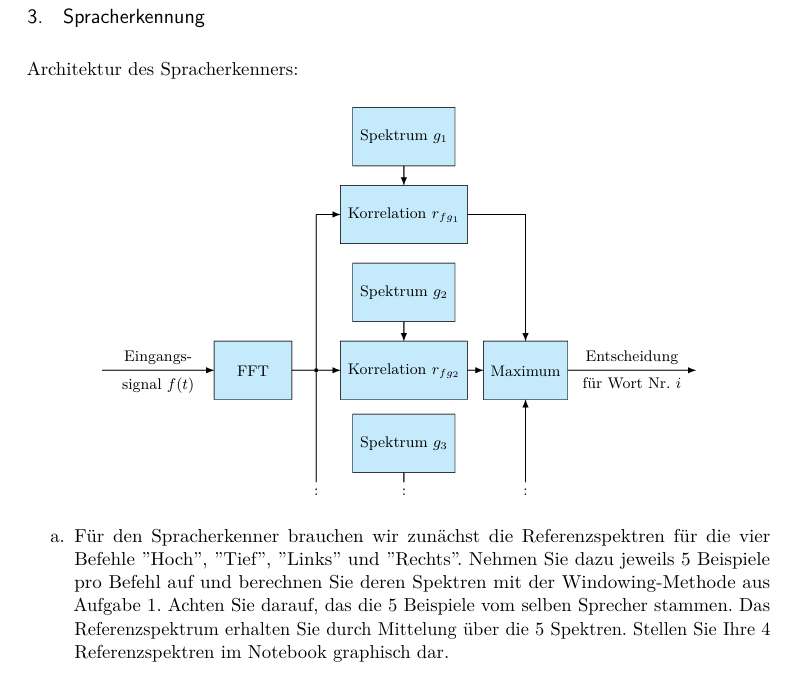

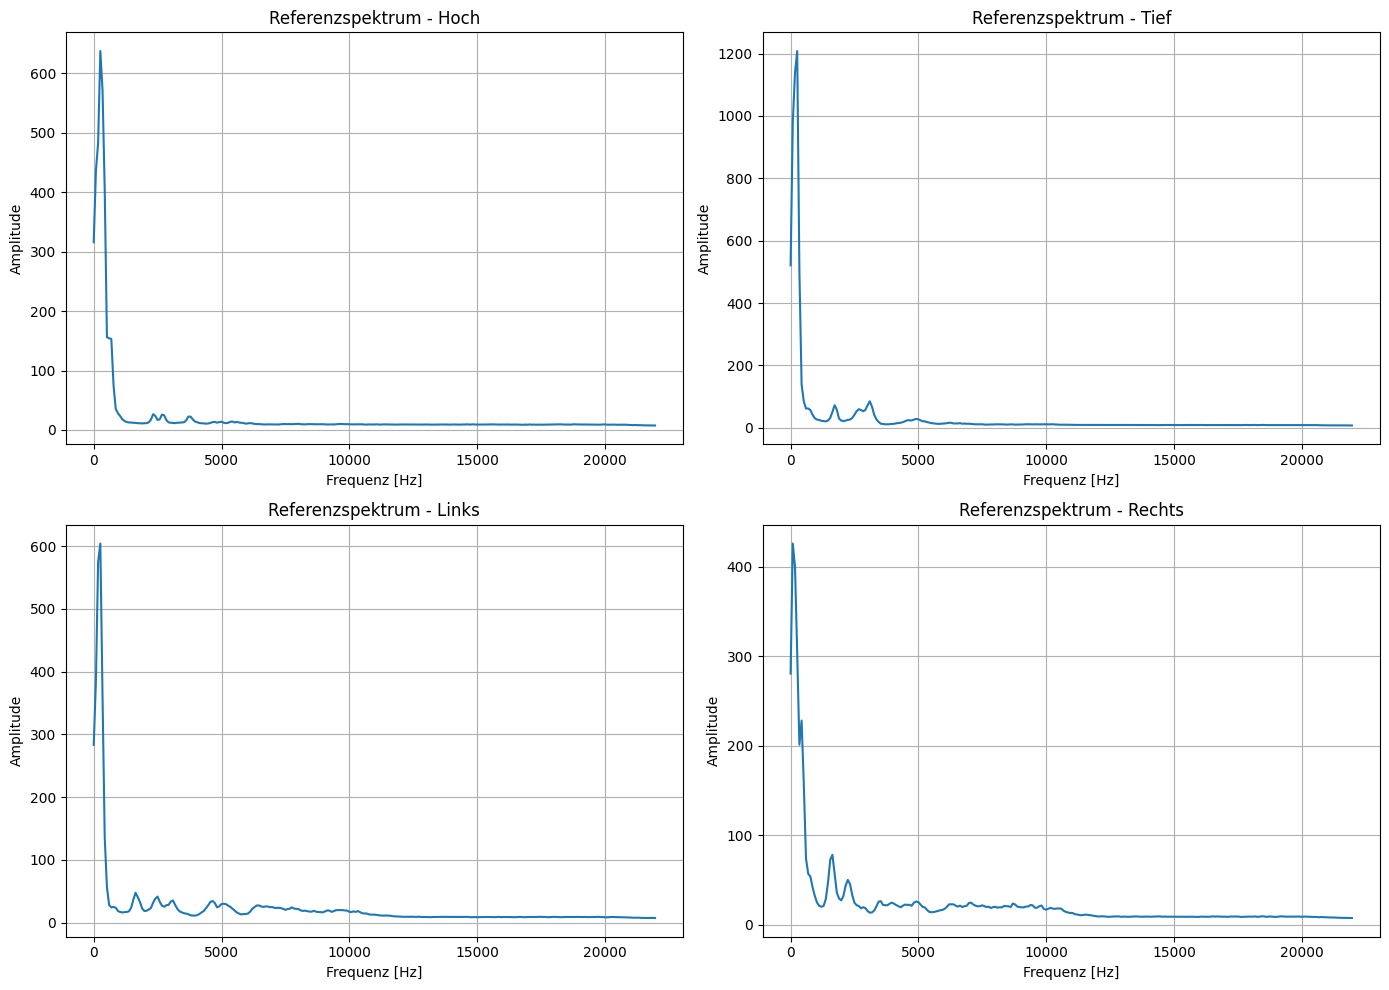

In [282]:

# Teilaufgabe a) Nehme jeweils 5 Beispiele und berechne deren Spektren mit der Windowing Methode

def specWindowing(signal_array):
    x_x_freq = []
    x_x_Amp = []
    for signal in signal_array:
        f_pos, A_pos = gauss_window_fft(signal)
        x_x_freq.append(f_pos)
        x_x_Amp.append(A_pos)
        
    return x_x_freq, x_x_Amp

# 0-4 Referenz bzw Trainingsdaten, 5-9 Testdaten Justin
J_H_freq, J_H_Amp = specWindowing(signal_array=J_h_u) # Spektren von Tief
J_T_freq, J_T_Amp = specWindowing(signal_array=J_t_u) # Spektren von Rechts
J_L_freq, J_L_Amp = specWindowing(signal_array=J_l_u) # Spektren von Links
J_R_freq, J_R_Amp = specWindowing(signal_array=J_r_u) # Spektren von Rechts

# Testdaten Nikita 0-9
N_H_freq, N_H_Amp = specWindowing(signal_array=N_h_u) # Spektren von Tief
N_T_freq, N_T_Amp = specWindowing(signal_array=N_t_u) # Spektren von Rechts
N_L_freq, N_L_Amp = specWindowing(signal_array=N_l_u) # Spektren von Links
N_R_freq, N_R_Amp = specWindowing(signal_array=N_r_u) # Spektren von Rechts

'''
for x in range(5):
    plotstart()
    plot(J_H_freq[x], J_H_Amp[x])
    plotend(f"Spektrum nach Gauss Window fft, Justin Hoch nr {x}", "Frequenzen in Hz", "Amplituden")
    gauss_spectrogram(J_h_u[x])

Audio(J_h_u[6], rate=44100)


'''

# Trainingsdaten
J_H_Amp_Ref = np.mean(J_H_Amp[:5], axis=0) # 5 Einträge der Hoch Amplituden für Referenz
J_T_Amp_Ref = np.mean(J_T_Amp[:5], axis=0) # 5 Einträge der Tief Amplituden für Referenz
J_L_Amp_Ref = np.mean(J_L_Amp[:5], axis=0) # 5 Einträge der Links Amplituden für Referenz
J_R_Amp_Ref = np.mean(J_R_Amp[:5], axis=0) # 5 Einträge der Rechts Amplituden für Referenz

freq_ref = J_H_freq[0] # Irrelevant was man hier nimmt, ich brauch das für die x achse im Plot

plt.figure(figsize=(14, 10))

# ---- Hoch ----
plt.subplot(2, 2, 1)
plt.plot(freq_ref, J_H_Amp_Ref)
plt.title("Referenzspektrum - Hoch")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Amplitude")
plt.grid(True)

# ---- Tief ----
plt.subplot(2, 2, 2)
plt.plot(freq_ref, J_T_Amp_Ref)
plt.title("Referenzspektrum - Tief")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Amplitude")
plt.grid(True)

# ---- Links ----
plt.subplot(2, 2, 3)
plt.plot(freq_ref, J_L_Amp_Ref)
plt.title("Referenzspektrum - Links")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Amplitude")
plt.grid(True)

# ---- Rechts ----
plt.subplot(2, 2, 4)
plt.plot(freq_ref, J_R_Amp_Ref)
plt.title("Referenzspektrum - Rechts")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()



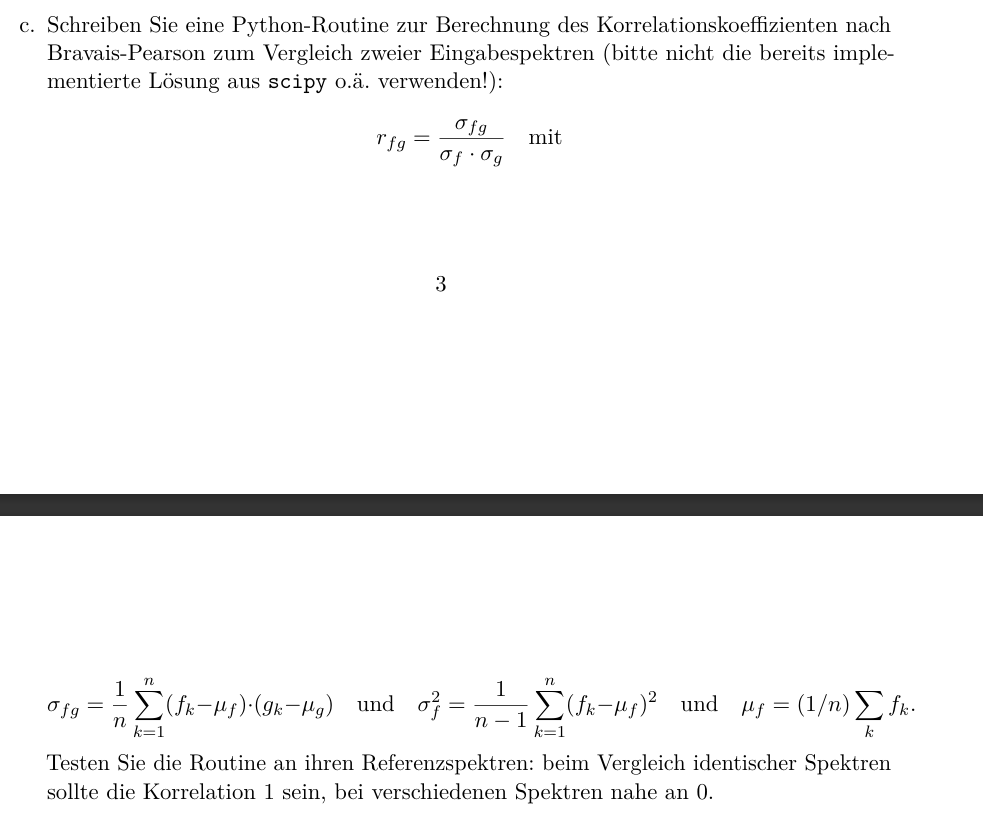

In [283]:
# Streuungsvarianz
def varianz(Spektrum):
    mu_f = np.mean(Spektrum)
    n = len(Spektrum)
    return np.sum((Spektrum - mu_f)**2) / (n - 1)

# Kovarianz
def kovarianz(known_Spektrum, unknown_Spektrum):
    # Beide Spektren auf gleiche Länge kürzen
    min_len = min(len(known_Spektrum), len(unknown_Spektrum))
    f = unknown_Spektrum[:min_len]
    g = known_Spektrum[:min_len]

    mu_f = np.mean(f)
    mu_g = np.mean(g)

    n = len(f)
    return np.sum((f - mu_f) * (g - mu_g)) / (n - 1)

# Die Pearson Formel
def rfg(kovarianz, varianz_unbekannt, varianz_bekannt):
    denom = np.sqrt(varianz_unbekannt) * np.sqrt(varianz_bekannt)
    if denom == 0:
        return 0  # Verhindert Division durch 0
    return kovarianz / denom

# Korrelation für deine Verwendung
def korr(eingangsSpektrum, refSpektrum):
    # Angleichen der Länge
    min_len = min(len(eingangsSpektrum), len(refSpektrum))
    f = eingangsSpektrum[:min_len]
    g = refSpektrum[:min_len]

    v1 = varianz(f)
    v2 = varianz(g)
    kova = kovarianz(g, f)
    r = rfg(kovarianz=kova, varianz_unbekannt=v1, varianz_bekannt=v2)

    return r

# Testen zweier Signale nach Pearson
def testSpektren(Spektrum_unbekannt, Spektrum_bekannt):
    # beide Spektren auf gleiche Länge bringen
    min_len = min(len(Spektrum_unbekannt), len(Spektrum_bekannt))
    f = Spektrum_unbekannt[:min_len]
    g = Spektrum_bekannt[:min_len]

    v1 = varianz(f)
    v2 = varianz(g)
    kova = kovarianz(g, f)   # Reihenfolge egal, Kovarianz ist symmetrisch
    r = rfg(kovarianz=kova, varianz_unbekannt=v1, varianz_bekannt=v2)

    print("-----------------------------")
    print(f"Die Korrelation r von = {r}")

    if r > 0.7:
        print("  sehr ähnlich")
    elif r > 0.3:
        print("  etwas ähnlich")
    else:
        print("  nicht ähnlich")



In [284]:
# Testen einiger Signale

print("\nBekannte Justin Hoch Spektren 0-4: ")
# Bekannte Spektren
testSpektren(J_H_Amp[0], J_H_Amp_Ref)
testSpektren(J_H_Amp[1], J_H_Amp_Ref)
testSpektren(J_H_Amp[2], J_H_Amp_Ref)
testSpektren(J_H_Amp[3], J_H_Amp_Ref)
testSpektren(J_H_Amp[4], J_H_Amp_Ref)

print("\nBekannte Justin Tief Spektren 0-4: ")
# Bekannte Spektren
testSpektren(J_T_Amp[0], J_T_Amp_Ref)
testSpektren(J_T_Amp[1], J_T_Amp_Ref)
testSpektren(J_T_Amp[2], J_T_Amp_Ref)
testSpektren(J_T_Amp[3], J_T_Amp_Ref)
testSpektren(J_T_Amp[4], J_T_Amp_Ref)


print("\nBekannte Justin Links Spektren 0-4: ")
# Bekannte Spektren
testSpektren(J_L_Amp[0], J_L_Amp_Ref)
testSpektren(J_L_Amp[1], J_L_Amp_Ref)
testSpektren(J_L_Amp[2], J_L_Amp_Ref)
testSpektren(J_L_Amp[3], J_L_Amp_Ref)
testSpektren(J_L_Amp[4], J_L_Amp_Ref)


print("\nBekannte Justin Rechts Spektren 0-4: ")
# Bekannte Spektren
testSpektren(J_R_Amp[0], J_R_Amp_Ref)
testSpektren(J_R_Amp[1], J_R_Amp_Ref)
testSpektren(J_R_Amp[2], J_R_Amp_Ref)
testSpektren(J_R_Amp[3], J_R_Amp_Ref)
testSpektren(J_R_Amp[4], J_R_Amp_Ref)

# Soweit alles Korrekt


Bekannte Justin Hoch Spektren 0-4: 
-----------------------------
Die Korrelation r von = 0.38490586813011574
  etwas ähnlich
-----------------------------
Die Korrelation r von = 0.9845180486447807
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9955141093271801
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9914390425435281
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9833231776313116
  sehr ähnlich

Bekannte Justin Tief Spektren 0-4: 
-----------------------------
Die Korrelation r von = 0.9253982267383624
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9947134259142124
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9963043032034005
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9963521783952288
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9909279773740591
  sehr ähnlich

Bekannte Justin Links Spektren 0-4: 
------

In [240]:
# Stichproben Unbekannte Daten

## Hoch
# Justin
print("--------------\nJustin Hoch:")
testSpektren(J_H_Amp[6], J_H_Amp_Ref)
testSpektren(J_H_Amp[9], J_H_Amp_Ref)
# Nikita
print("--------------\nNikita Hoch:")
testSpektren(N_H_Amp[2], J_H_Amp_Ref)
testSpektren(N_H_Amp[7], J_H_Amp_Ref)

## Tief
# Justin
print("--------------\nJustin Tief:")
testSpektren(J_T_Amp[8], J_T_Amp_Ref)
testSpektren(J_T_Amp[5], J_T_Amp_Ref)
# Nikita
print("--------------\nNikita Tief:")
testSpektren(N_T_Amp[1], J_T_Amp_Ref)
testSpektren(N_T_Amp[0], J_T_Amp_Ref)


## Links
# Justin
print("--------------\nJustin Links:")
testSpektren(J_L_Amp[7], J_L_Amp_Ref)
testSpektren(J_L_Amp[8], J_L_Amp_Ref)
# Nikita
print("--------------\nNikita Links:")
testSpektren(N_L_Amp[0], J_L_Amp_Ref)
testSpektren(N_L_Amp[9], J_L_Amp_Ref)


## Rechts
# Justin
print("--------------\nJustin Rechts:")
testSpektren(J_R_Amp[9], J_R_Amp_Ref)
testSpektren(J_R_Amp[7], J_R_Amp_Ref)
# Nikita
print("--------------\nNikita Rechts:")
testSpektren(N_R_Amp[6], J_R_Amp_Ref)
testSpektren(N_R_Amp[4], J_R_Amp_Ref)

## Völlig verschiedene Wörter
print("--------------\Justin Unterschiedlich:")
# Justin
testSpektren(J_R_Amp[1], J_L_Amp_Ref)
testSpektren(J_T_Amp[6], J_H_Amp_Ref)
# Nikita
testSpektren(N_H_Amp[0], J_T_Amp_Ref)
testSpektren(N_L_Amp[5], J_R_Amp_Ref)

## Völlig verschiedene Wörter und referenzen
print("--------------\Justin Unterschiedlich:")
# Justin
testSpektren(J_R_Amp[1], N_L_Amp[5])
testSpektren(J_T_Amp[6], N_H_Amp[3])
# Nikita
testSpektren(N_H_Amp[0], J_R_Amp[1])
testSpektren(N_L_Amp[5], J_T_Amp[6])

## Gleiche Wörter, verschiedene Sprecher
testSpektren(J_R_Amp[1], N_R_Amp[5])
testSpektren(J_T_Amp[6], N_T_Amp[3])


--------------
Justin Hoch:
-----------------------------
Die Korrelation r von = 0.9836503246956583
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.9823726488503833
  sehr ähnlich
--------------
Nikita Hoch:
-----------------------------
Die Korrelation r von = 0.7984908417204043
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.8187486445341987
  sehr ähnlich
--------------
Justin Tief:
-----------------------------
Die Korrelation r von = 0.9887150816947317
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.8260488007587165
  sehr ähnlich
--------------
Nikita Tief:
-----------------------------
Die Korrelation r von = 0.8857900962624774
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.8109482741543707
  sehr ähnlich
--------------
Justin Links:
-----------------------------
Die Korrelation r von = 0.9881134565405872
  sehr ähnlich
-----------------------------
Die Korrelation r von = 0.99129685826

Es erkennt es relativ gut, warum?
Weil Sprachmuster die selben Frequenzen verfolgen. Deswegen kann man, obwohl die Stimmlage unterschiedlich ist, eine Deutliche Korrelation erkennen zwischen den Sprachen. Unterschiedlich wird es erst dann, wenn komplett andere wörter verwendet werden.

Hinzu kommen noch betonungen und aussprechweise. Jenachdem ob man wörter flach ausspricht können diese auch, frequenz mäßig, ähnlich sein.
Außerdem Glättet das Windowing die Frequenzen so stark, dass Wörter nicht mehr herrauszufinden sind.

Natürlich kann auch der gegebene Datensatz selber fehlerhaft sein. Unterschiedliche Lautstärke, übersteuertes Mikrofon, starkes Rauschen etc.

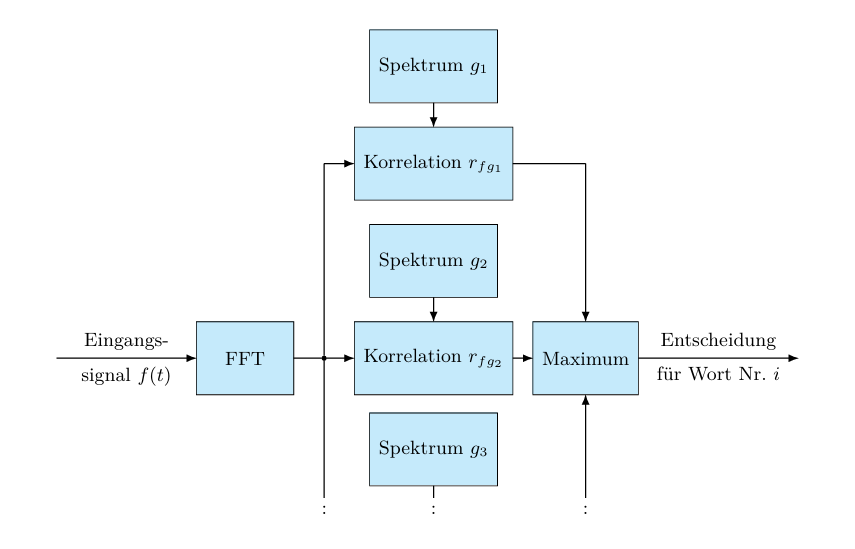

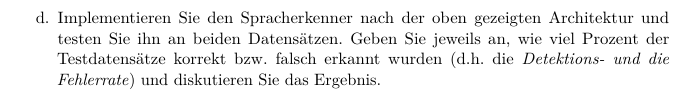

In [270]:
# Fargbige ausgabe weil es schön aussieht
GREEN = "\033[92m"
BOLD = "\033[1m"
RED = "\033[91m"
CYAN = "\033[96m"
RESET = "\033[0m"
YELLOW = "\033[93m"
LILA = "\033[95m"


def sprachErkenner(Eingangssignal, true_label=None):
    # FFT
    f_pos, A_pos = gauss_window_fft(Eingangssignal)

    # Korrelationen
    g1 = korr(A_pos, J_H_Amp_Ref)
    g2 = korr(A_pos, J_T_Amp_Ref)
    g3 = korr(A_pos, J_L_Amp_Ref)
    g4 = korr(A_pos, J_R_Amp_Ref)

    korrelationen = {
        "H": g1,
        "T": g2,
        "L": g3,
        "R": g4
    }

    pred_label = max(korrelationen, key=korrelationen.get)
    best_corr = korrelationen[pred_label]

    # Fehlerberechnung
    sorted_corr = sorted(korrelationen.values(), reverse=True)
    best = sorted_corr[0]
    second_best = sorted_corr[1]

    diff_error = best - second_best
    sum_corr = sum(sorted_corr)
    uncertainty = 1 - (best / sum_corr) if sum_corr != 0 else 1.0

    # Ausgabe
    if true_label is not None:
        print(f"Vorhersage: {LILA}{pred_label}{RESET} (r = {best_corr:.3f}), tatsächliches Label: {YELLOW}{true_label}{RESET}")
    else:
        print(f"Vorhersage: {LILA}{pred_label}{RESET} (r = {best_corr:.3f})")

    print(f"Fehler Δr: {diff_error:.3f}")
    print(f"Unsicherheit: {uncertainty:.3f}")
    print("------------------------------------------")

    return pred_label, diff_error, uncertainty


In [271]:
# Testen vom Spracherkenner
print("Justin: ")
for i in range(10):
    print(i)
    sprachErkenner(N_l_u[i])

Audio(N_t_u[5], rate=44100)

Justin: 
0
Vorhersage: L (r = 0.891)
Fehler Δr: 0.024
Unsicherheit: 0.731
------------------------------------------
1
Vorhersage: L (r = 0.880)
Fehler Δr: 0.028
Unsicherheit: 0.730
------------------------------------------
2
Vorhersage: L (r = 0.880)
Fehler Δr: 0.026
Unsicherheit: 0.731
------------------------------------------
3
Vorhersage: L (r = 0.873)
Fehler Δr: 0.024
Unsicherheit: 0.727
------------------------------------------
4
Vorhersage: L (r = 0.880)
Fehler Δr: 0.024
Unsicherheit: 0.731
------------------------------------------
5
Vorhersage: L (r = 0.865)
Fehler Δr: 0.006
Unsicherheit: 0.739
------------------------------------------
6
Vorhersage: L (r = 0.889)
Fehler Δr: 0.020
Unsicherheit: 0.732
------------------------------------------
7
Vorhersage: L (r = 0.890)
Fehler Δr: 0.022
Unsicherheit: 0.731
------------------------------------------
8
Vorhersage: L (r = 0.898)
Fehler Δr: 0.024
Unsicherheit: 0.735
------------------------------------------
9
Vorhersage: L (r 

In [274]:
def evaluate_model(signals, true_labels):
    total = len(signals)
    correct = 0
    wrong = 0

    for signal, label in zip(signals, true_labels):
        pred, _, _ = sprachErkenner(signal, true_label=label)

        if pred == label:
            correct += 1
        else:
            wrong += 1

    detektionsrate = (correct / total) * 100
    fehlerrate = (wrong / total) * 100

    print(f"{BOLD}{GREEN}----- Auswertung -----")
    print(f"Anzahl Testdaten:          {total}")
    print(f"Richtig erkannt:           {correct}")
    print(f"Falsch erkannt:            {wrong}")
    print(f"Detektionsrate:            {detektionsrate:.2f} %")
    print(f"{RED}Fehlerrate:                {fehlerrate:.2f}{RESET} %")
    print(f"------------------------{RESET}")

    return detektionsrate, fehlerrate


# Daten Labeln
# Justin Testsignale
justin_signals = (
    J_h_u[5:] + 
    J_t_u[5:] + 
    J_l_u[5:] + 
    J_r_u[5:]
)

justin_labels = (
    ["H"] * len(J_h_u[5:]) +
    ["T"] * len(J_t_u[5:]) +
    ["L"] * len(J_l_u[5:]) +
    ["R"] * len(J_r_u[5:])
)

# Nikita Testsignale
nikita_signals = (
    N_h_u + 
    N_t_u + 
    N_l_u + 
    N_r_u
)

nikita_labels = (
    ["H"] * len(N_h_u) +
    ["T"] * len(N_t_u) +
    ["L"] * len(N_l_u) +
    ["R"] * len(N_r_u)
)


In [275]:
# Modell Testen

print(f"{CYAN}=== Justin (Trainingssprecher) ==={RESET}")
evaluate_model(justin_signals, justin_labels)

print(f"{RED}=== Nikita (Testsprecher) ==={RESET}")
evaluate_model(nikita_signals, nikita_labels)


=== Justin (Trainingssprecher) ===
Vorhersage: R (r = 0.586), tatsächliches Label: H
Fehler Δr: 0.110
Unsicherheit: 0.704
------------------------------------------
Vorhersage: H (r = 0.984), tatsächliches Label: H
Fehler Δr: 0.077
Unsicherheit: 0.732
------------------------------------------
Vorhersage: H (r = 0.986), tatsächliches Label: H
Fehler Δr: 0.061
Unsicherheit: 0.735
------------------------------------------
Vorhersage: H (r = 0.979), tatsächliches Label: H
Fehler Δr: 0.071
Unsicherheit: 0.733
------------------------------------------
Vorhersage: H (r = 0.982), tatsächliches Label: H
Fehler Δr: 0.040
Unsicherheit: 0.738
------------------------------------------
Vorhersage: R (r = 0.848), tatsächliches Label: T
Fehler Δr: 0.022
Unsicherheit: 0.739
------------------------------------------
Vorhersage: T (r = 0.997), tatsächliches Label: T
Fehler Δr: 0.009
Unsicherheit: 0.737
------------------------------------------
Vorhersage: T (r = 0.998), tatsächliches Label: T
Fehle

(52.5, 47.5)